In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


#Parte 1

Gráfico de linha — faturamento mensal

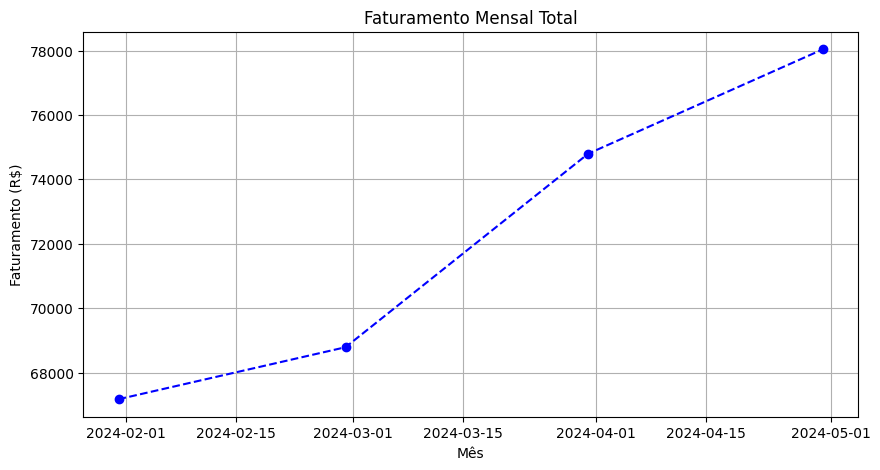

In [10]:
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10, 5))
plt.plot(faturamento_mensal.index, faturamento_mensal.values,
         marker='o', linestyle='--', color='blue')

plt.title('Faturamento Mensal Total')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True)

plt.show()

Gráfico de barras — vendas por categoria

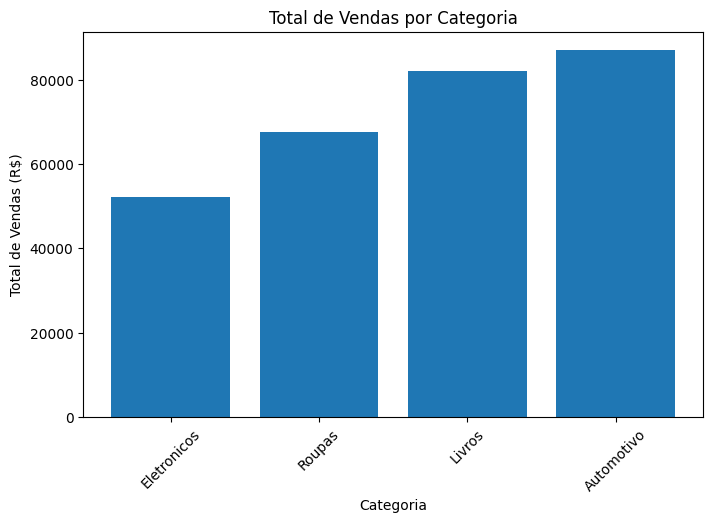

In [11]:
vendas_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(vendas_categoria.index, vendas_categoria.values)

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')
plt.xticks(rotation=45)

plt.show()

Histograma — distribuição dos valores

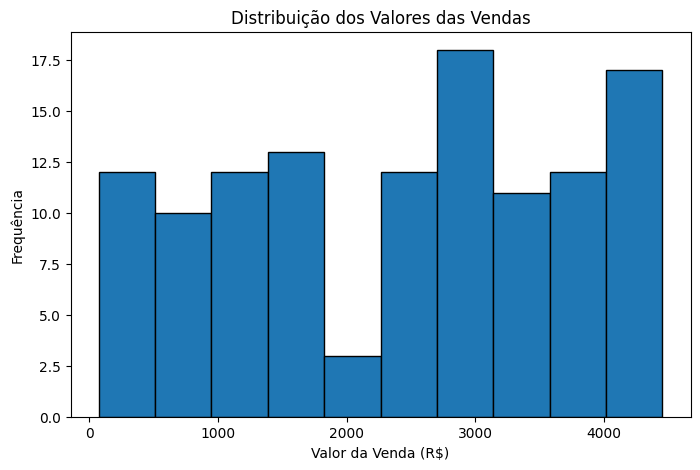

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df['valor'], bins=10, edgecolor='black')

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Frequência')

plt.show()

# Parte 2

Subplots 2 × 1

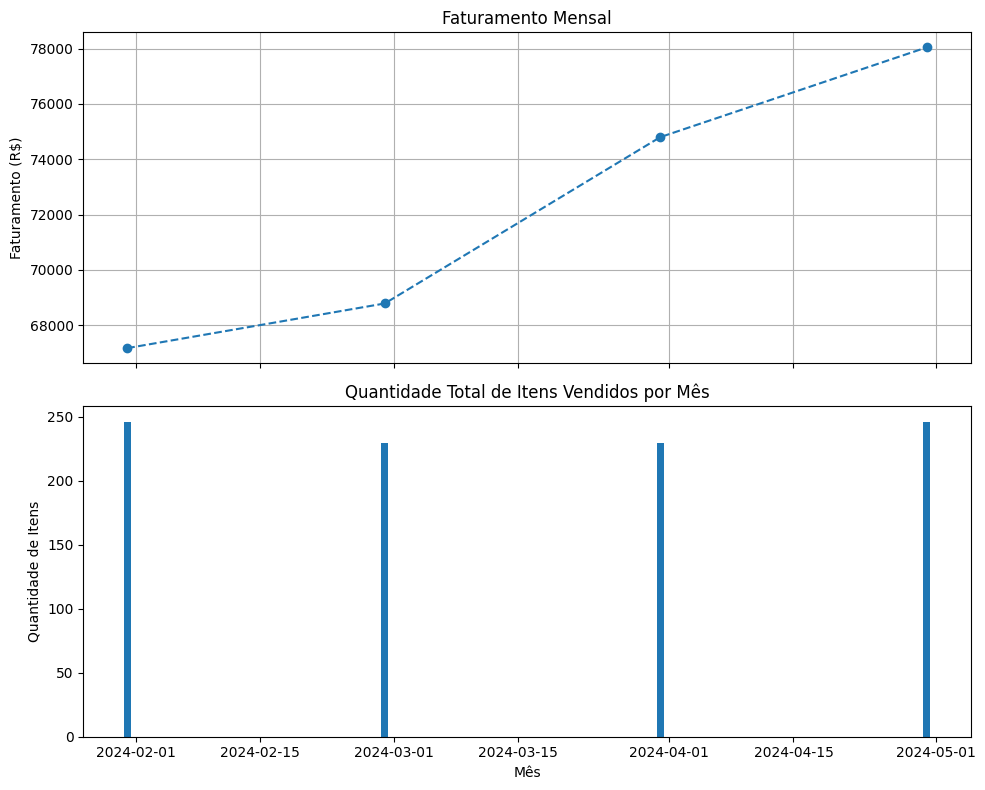

In [7]:
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()
quantidade_mensal = df.set_index('data')['quantidade'].resample('ME').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Gráfico superior
ax1.plot(faturamento_mensal.index, faturamento_mensal.values,
         marker='o', linestyle='--')

ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True)

# Gráfico inferior
ax2.bar(quantidade_mensal.index, quantidade_mensal.values)

ax2.set_title('Quantidade Total de Itens Vendidos por Mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de Itens')

plt.tight_layout()
plt.show()

Dois eixos Y com twinx()

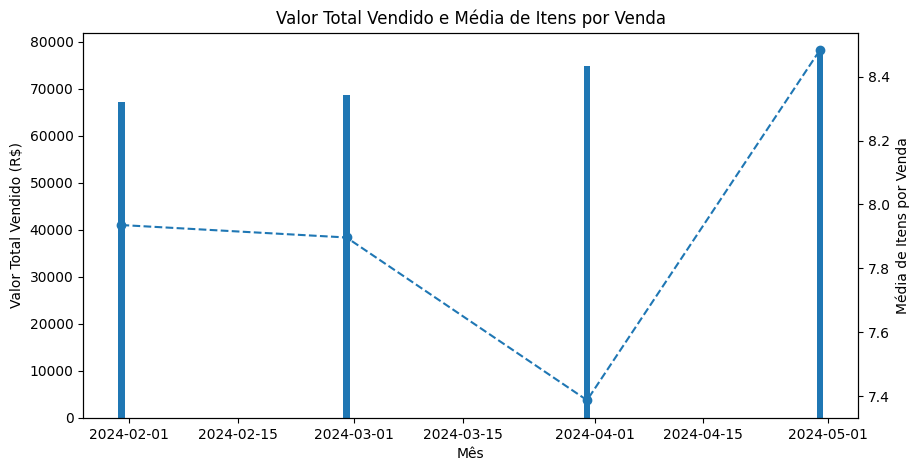

In [8]:
valor_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()
media_quantidade = df.set_index('data')['quantidade'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(10, 5))

# Eixo Y primário
ax.bar(valor_mensal.index, valor_mensal.values)

ax.set_xlabel('Mês')
ax.set_ylabel('Valor Total Vendido (R$)')
ax.set_title('Valor Total Vendido e Média de Itens por Venda')

# Eixo Y secundário
ax2 = ax.twinx()

ax2.plot(media_quantidade.index, media_quantidade.values,
         marker='o', linestyle='--')

ax2.set_ylabel('Média de Itens por Venda')

plt.show()

Anotação no mês de maior faturamento

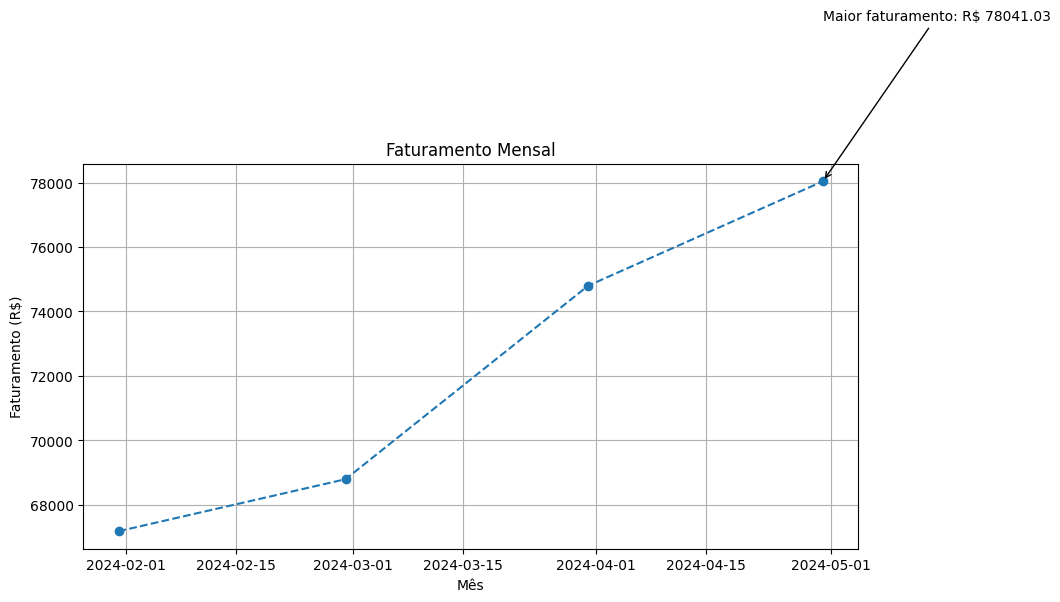

In [9]:
faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(faturamento_mensal.index, faturamento_mensal.values,
        marker='o', linestyle='--')

# Encontrando o maior faturamento
mes_maior = faturamento_mensal.idxmax()
valor_maior = faturamento_mensal.max()

# Anotação
ax.annotate(
    f'Maior faturamento: R$ {valor_maior:.2f}',
    xy=(mes_maior, valor_maior),
    xytext=(mes_maior, valor_maior + 5000),
    arrowprops=dict(arrowstyle='->')
)

ax.set_title('Faturamento Mensal')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True)

plt.show()

# Parte 3

Tabela dinâmica

In [12]:
tabela_pivot = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum'
)

print(tabela_pivot)

estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    6992.96  16333.39  26783.38  10122.88  26727.57
Eletronicos  14211.94  13453.06   1154.47  13966.62   9372.80
Livros        4318.03  25667.11   9659.57  19302.59  23104.72
Roupas       26968.88   9876.74  11120.83   4809.04  14856.77


Heatmap com plt.imshow()

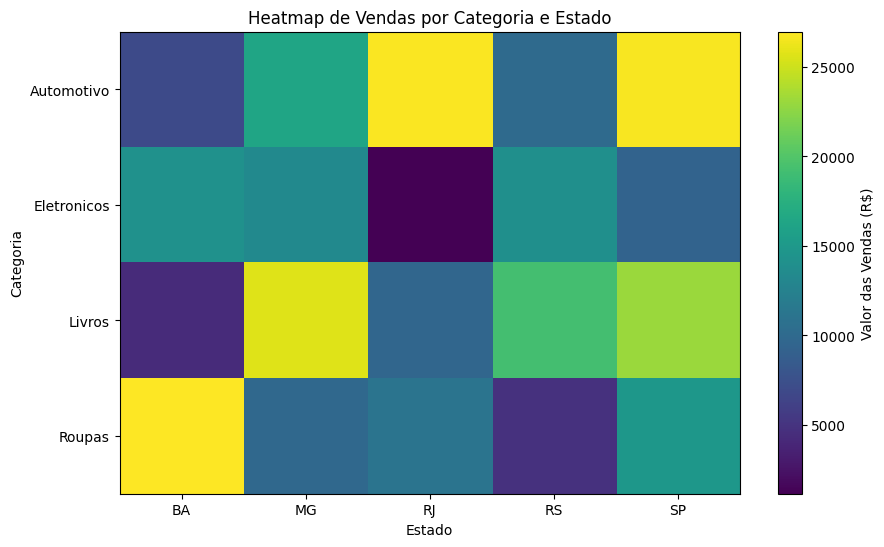

In [13]:
plt.figure(figsize=(10, 6))

plt.imshow(tabela_pivot, aspect='auto')

plt.colorbar(label='Valor das Vendas (R$)')

plt.xticks(
    ticks=np.arange(len(tabela_pivot.columns)),
    labels=tabela_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(tabela_pivot.index)),
    labels=tabela_pivot.index
)

plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.title('Heatmap de Vendas por Categoria e Estado')

plt.show()

Salvar o Heatmap em PNG com 300 DPI

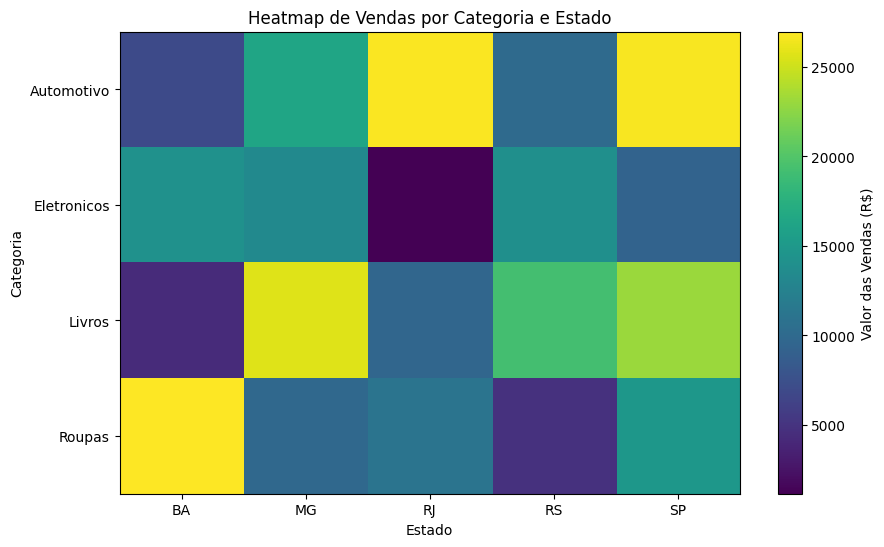

In [14]:
plt.figure(figsize=(10, 6))

plt.imshow(tabela_pivot, aspect='auto')

plt.colorbar(label='Valor das Vendas (R$)')

plt.xticks(
    ticks=np.arange(len(tabela_pivot.columns)),
    labels=tabela_pivot.columns
)

plt.yticks(
    ticks=np.arange(len(tabela_pivot.index)),
    labels=tabela_pivot.index
)

plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.title('Heatmap de Vendas por Categoria e Estado')

plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()